In [2]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [5]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 
years: 2010, 2011, 2012, 2013, 2018, 2019, 2020, 2021, 


In [6]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'

In [7]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.390000,11.935000,6.845,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,0.015560,0.015560,0.015560,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,5,0,0
1,21.94079,40.97703,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.657273,11.324545,5.990,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,0.248551,0.248551,0.248551,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,0,0
3,23.98253,40.91510,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.742500,13.120000,8.365,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,0.055994,0.055994,0.055994,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,20,0,0
4,23.69108,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,747.0,16994.0,24.5,46.91682,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.0,0.0,0.0,0.0,11.447500,15.240000,7.655,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,1.750566,1.750566,1.750566,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,4,0,0


In [8]:
#Check months

dataset = dataset.query('month >= 6 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [9]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-06-01,κεντρικης μακεδονιας,αλεξανδρειας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,478.8,38293.0,86.8,46.44911,0.237090,-0.048711,-0.317377,0.048711,0.233606,-0.039714,-0.304677,0.039714,0.064241,0.055555,0.021262,0.055555,27.490000,38.045000,16.935000,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,27.661434,69.883681,634.525996,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,5,10,0
1,21.94079,40.97703,2010-06-01,κεντρικης μακεδονιας,αλμωπιας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,985.8,24924.0,28.0,46.48134,0.610494,0.297777,-0.269769,-0.297777,0.589813,0.268988,-0.282681,-0.268988,0.054153,0.046797,0.051947,0.046797,19.087273,24.759091,13.415455,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,19.182475,53.285836,708.081877,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
2,22.89198,40.65603,2010-06-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,0.158598,-0.002042,-0.195420,0.002042,0.161290,-0.000149,-0.195554,0.000149,0.079131,0.039658,0.030081,0.039658,26.500000,35.950000,17.050000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,60.840037,99.001511,625.519261,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,14,0
3,23.98253,40.91510,2010-06-01,κεντρικης μακεδονιας,αμφιπολης,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,411.8,7169.0,22.3,47.42581,0.600695,0.348246,-0.219345,-0.348246,0.564287,0.283836,-0.257383,-0.283836,0.049732,0.050856,0.027357,0.050856,24.495000,30.690000,18.300000,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,29.119374,48.335329,661.806941,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,20,40,0
4,23.69108,40.49593,2010-06-01,κεντρικης μακεδονιας,αριστοτελη,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,747.0,16994.0,24.5,46.91682,0.517065,0.247244,-0.249138,-0.247244,0.548352,0.286086,-0.228926,-0.286086,0.042899,0.042628,0.027381,0.042628,19.367500,24.000000,14.735000,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,27.828753,56.447650,608.274993,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,4,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4851,22.14670,40.82294,2021-08-16,κεντρικης μακεδονιας,σκυδρας,16,8,33,2021,-0.101168,-0.994869,-8.660254e-01,-0.5,-0.696551,-0.717507,239.5,18080.0,84.3,46.44339,0.445122,0.014416,-0.427180,-0.014416,0.443690,0.017735,-0.421358,-0.017735,0.118285,0.115395,0.067481,0.115395,30.280000,37.640000,22.920000,8.027348,-1.694000,16.188258,3.720184,18.65

In [10]:
dataset['lau1'].unique().shape

(38,)

In [11]:
print(f'Number of LAU1 Units in {NUTS2}: {len(dataset.lau1.unique())}')

Number of LAU1 Units in CMacedonia: 38


In [12]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,291,250,541,11.14%
1,2011,356,31,387,7.97%
2,2012,361,20,381,7.85%
3,2013,363,21,384,7.91%
4,2014,380,0,380,7.83%
5,2015,380,0,380,7.83%
6,2016,380,0,380,7.83%
7,2017,380,0,380,7.83%
8,2018,311,117,428,8.81%
9,2019,344,53,397,8.18%


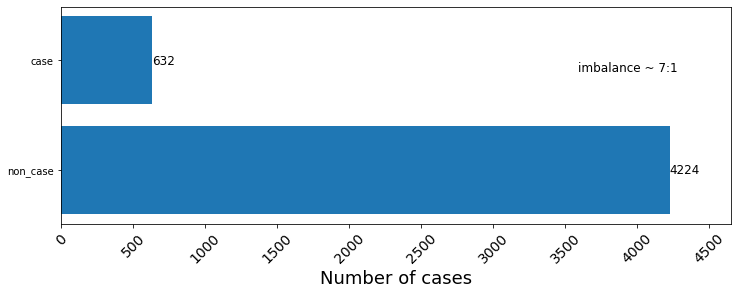

In [13]:
plot_imbalance(dataset)

In [14]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [15]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:4 || ##
Year: 2011 || w0:1, w1:3 || ##
Year: 2012 || w0:1, w1:3 || ##
Year: 2013 || w0:1, w1:3 || ##
Year: 2014 || w0:1, w1:3 || ##
Year: 2015 || w0:1, w1:3 || ##
Year: 2016 || w0:1, w1:3 || ##
Year: 2017 || w0:1, w1:3 || ##
Year: 2018 || w0:1, w1:3 || ##
Year: 2019 || w0:1, w1:3 || ##
Year: 2020 || w0:1, w1:3 || ##
Year: 2021 || w0:1, w1:3 || ##


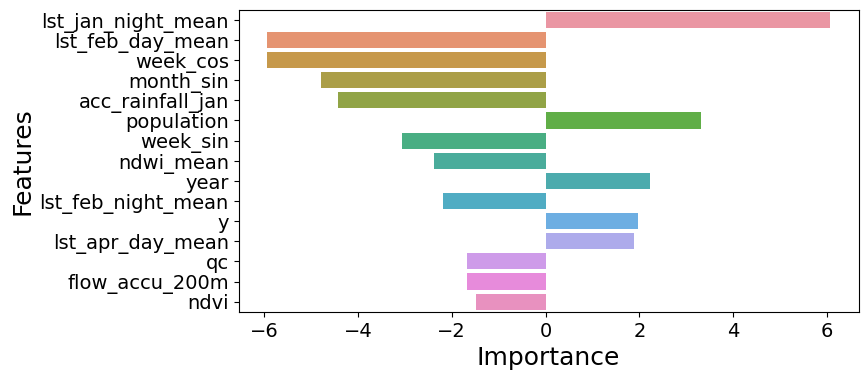

In [16]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

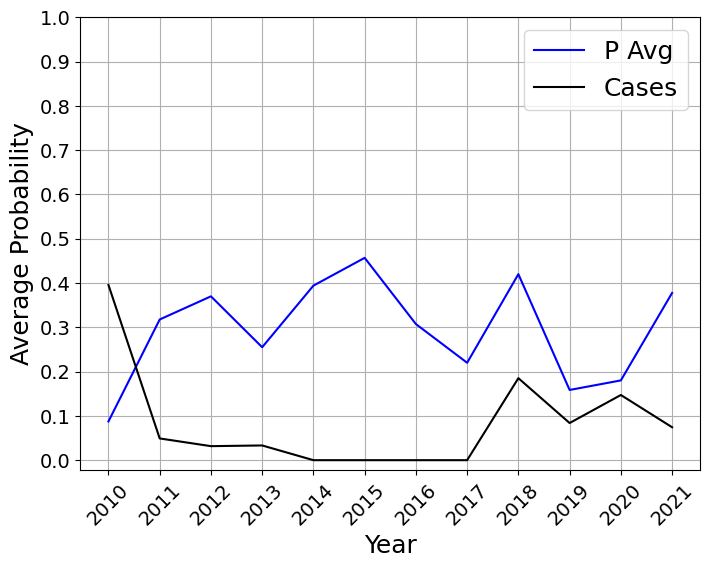

In [17]:
plot_trend_curve(results_test, list(dsc['case']))

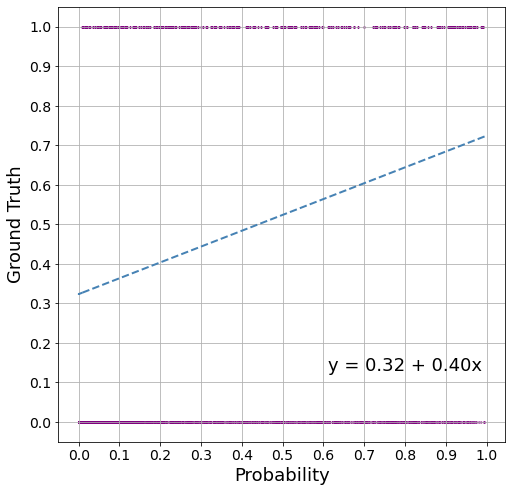

In [18]:
plot_probability_curve(results_test)

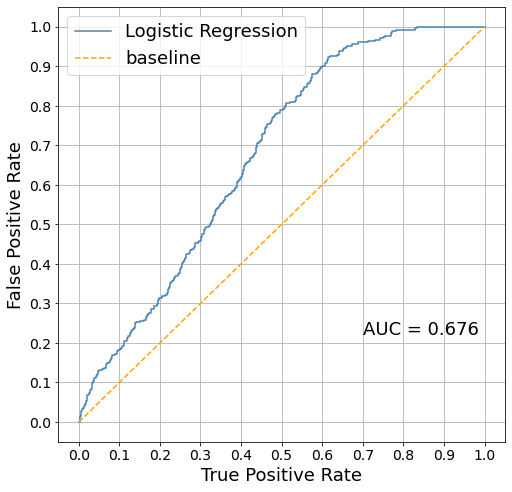

In [19]:
plot_roc_curve(results_test)

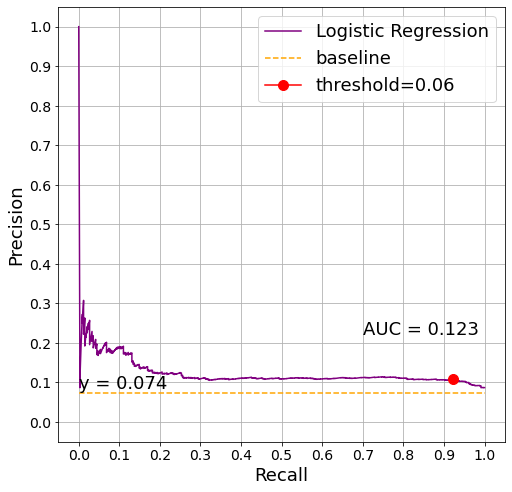

In [20]:
plot_pr_curve(results_test, plot_fbeta=True)

In [21]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 4, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 34.00%
Weighted Average: 41.65%

Random Average: 19.63%
Random Weighted Average: 25.44%


In [22]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
1,16/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
2,01/07/2010,1,0,0.08,1,0.00 %,0.00,8.00 %,0.0800
3,16/07/2010,12,3,1.28,4,75.00 %,0.75,32.00 %,0.3200
4,01/08/2010,23,4,2.33,4,100.00 %,1.00,58.25 %,0.5825
...,...,...,...,...,...,...,...,...,...
115,16/08/2021,8,2,0.74,4,50.00 %,0.50,18.50 %,0.1850
116,01/09/2021,4,1,0.41,4,25.00 %,0.25,10.25 %,0.1025
117,16/09/2021,1,1,0.11,1,100.00 %,1.00,11.00 %,0.1100
118,01/10/2021,1,0,0.13,1,0.00 %,0.00,13.00 %,0.1300


In [23]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2010,89,16,9.25,21,76.19 %,0.7619,44.05 %,0.4405
1,2011,24,7,2.50,17,41.18 %,0.4118,14.71 %,0.1471
2,2012,19,3,2.13,19,15.79 %,0.1579,11.21 %,0.1121
3,2013,17,1,1.82,17,5.88 %,0.0588,10.71 %,0.1071
4,2014,0,0,0.00,0,nan %,NaN,nan %,NaN
5,2015,0,0,0.00,0,nan %,NaN,nan %,NaN
6,2016,0,0,0.00,0,nan %,NaN,nan %,NaN
7,2017,0,0,0.00,0,nan %,NaN,nan %,NaN
8,2018,69,9,7.12,29,31.03 %,0.3103,24.55 %,0.2455
9,2019,36,5,3.60,20,25.00 %,0.2500,18.00 %,0.1800


In [21]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.1, beta = 4)

In [22]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,89.0,0.2737,0.7908,0.6154,0.7191,0.7120,0.4811
1,2011,24.0,0.6237,0.7008,0.1013,1.0000,0.6570,0.4929
2,2012,19.0,0.6395,0.6620,0.0741,0.9474,0.5594,0.7767
3,2013,17.0,0.5632,0.6979,0.0748,0.9412,0.5597,0.3900
4,2014,0.0,0.6789,0.3211,0.0000,0.0000,0.0000,0.7441
5,2015,0.0,0.7211,0.2789,0.0000,0.0000,0.0000,0.9747
6,2016,0.0,0.6079,0.3921,0.0000,0.0000,0.0000,0.5034
7,2017,0.0,0.5263,0.4737,0.0000,0.0000,0.0000,0.3242
8,2018,69.0,0.7237,0.6511,0.2436,0.9710,0.8260,0.6713
9,2019,36.0,0.4447,0.6993,0.1716,0.8056,0.6617,0.3341


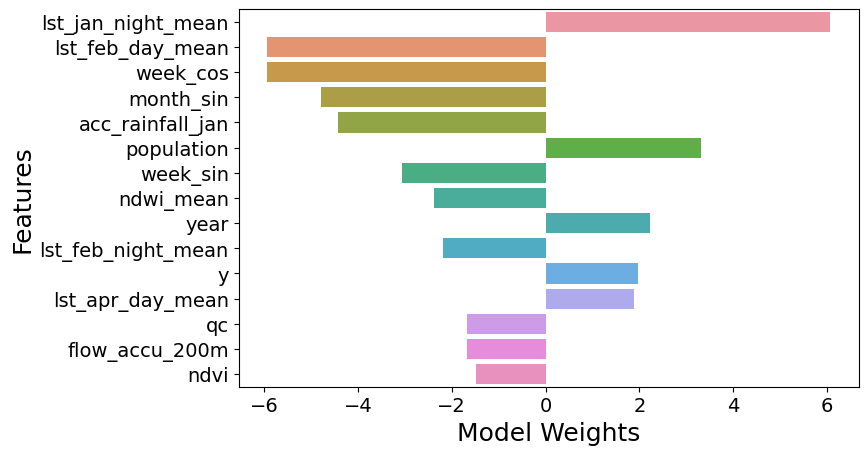

In [23]:
plot_feature_importance(coefficients, feature_names,  x_label = 'Model Weights', top = 15, figure_size = (8, 5))

In [24]:
results_test

,x,y,municipality,day,month,year,case,probability
0,22.71688,40.59973,δελτα,16,8,2012,0,0.994850
1,22.71688,40.59973,δελτα,1,9,2012,0,0.994683
2,22.71688,40.59973,δελτα,1,8,2012,0,0.994571
3,22.89198,40.65603,αμπελοκηπων μενεμενης,16,8,2012,0,0.994360
4,22.90326,40.67609,κορδελιου ευοσμου,16,8,2012,0,0.993613
...,...,...,...,...,...,...,...,...
4555,23.98253,40.91510,αμφιπολης,1,6,2012,0,0.000216
4556,23.05120,40.60697,πυλαιας χορτιατη,1,6,2010,0,0.000145
4557,22.95686,40.68150,παυλου μελα,1,6,2010,0,0.000140
4558,23.82811,40.11026,σιθωνιας,16,10,2021,0,0.000133
